# 5. Linear Forecasting

## Autocorrelation

C:\Users\westenb\AppData\Local\Temp\ipykernel_67176\1409492870.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, frameon=False, loc='upper right')


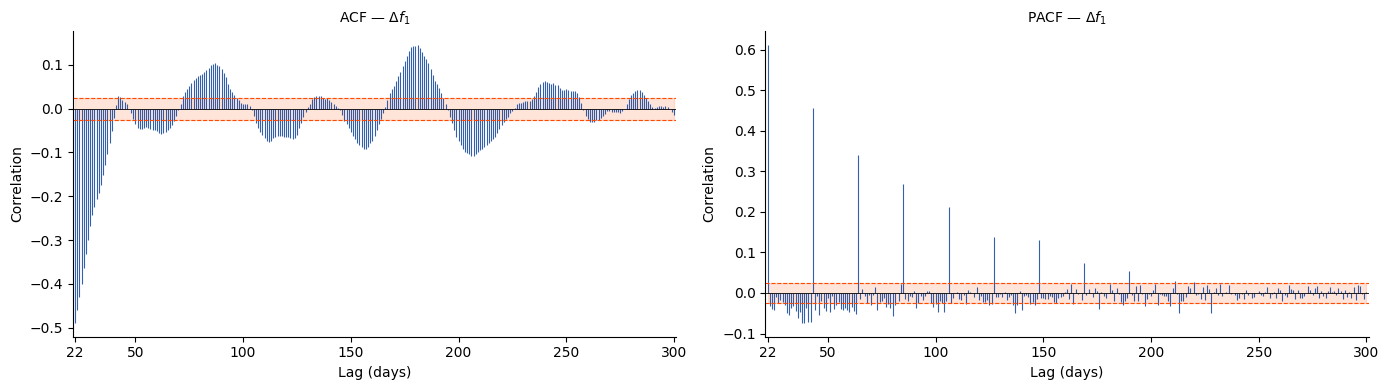

C:\Users\westenb\AppData\Local\Temp\ipykernel_67176\1409492870.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, frameon=False, loc='upper right')


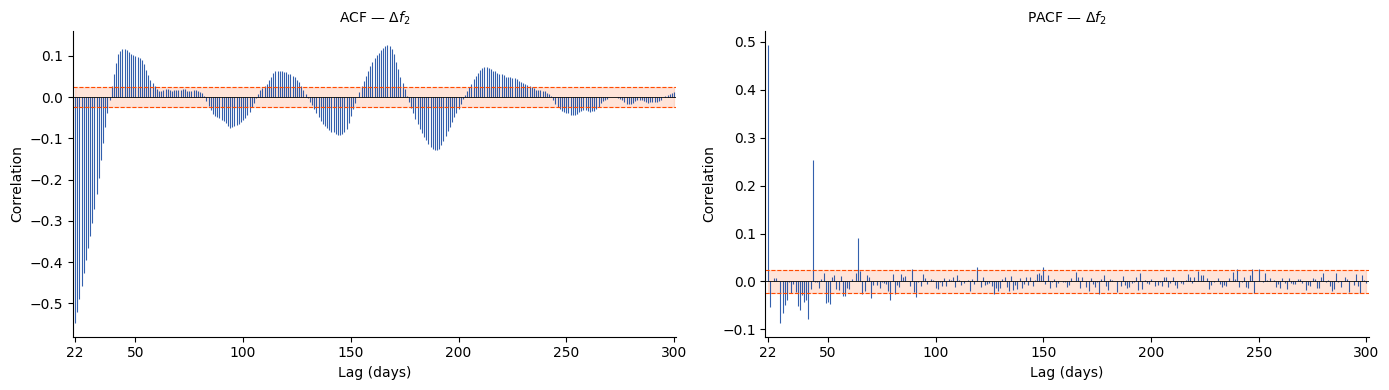

C:\Users\westenb\AppData\Local\Temp\ipykernel_67176\1409492870.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, frameon=False, loc='upper right')


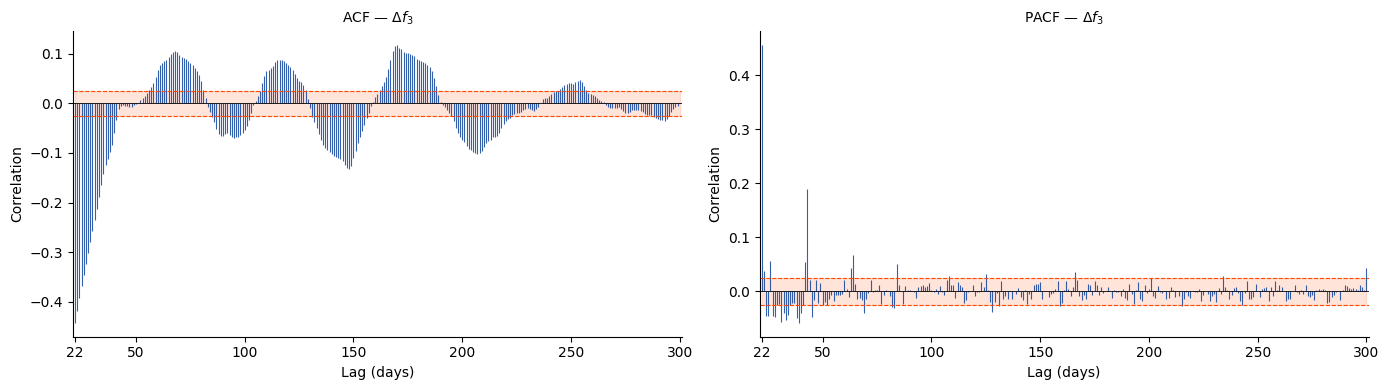

C:\Users\westenb\AppData\Local\Temp\ipykernel_67176\1409492870.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, frameon=False, loc='upper right')


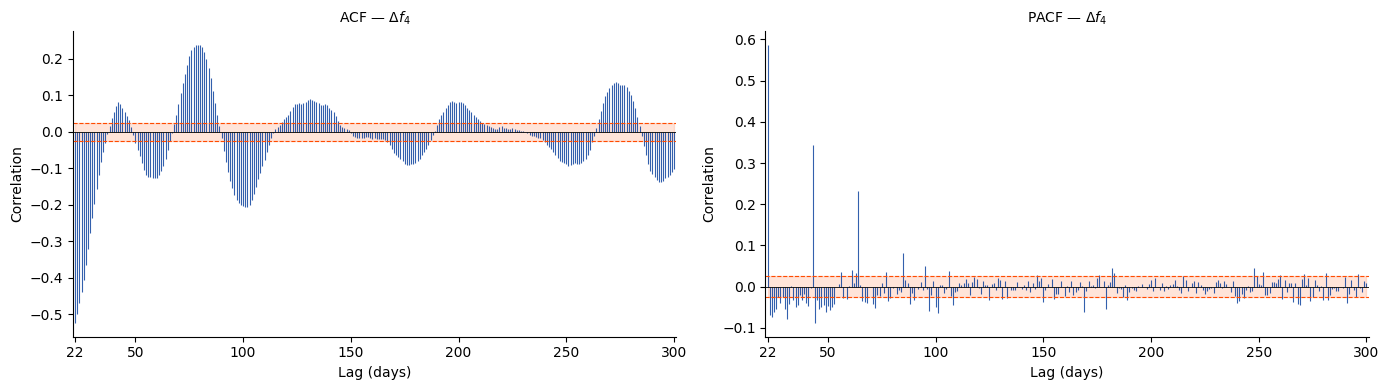


\begin{table}[htbp]
\centering
\caption{ACF and PACF of 21-day PC Factor Changes at Selected Lags. 
$^{*}$ denotes significance at the 95\% level ($|r| > 1.96/\sqrt{N}$).}
\label{tab:acf_pacf_pca4}
\begin{tabular}{lrrrrrrrr}
\hline\hline
Lag & \multicolumn{2}{c}{PC1} & \multicolumn{2}{c}{PC2} & \multicolumn{2}{c}{PC3} & \multicolumn{2}{c}{PC4} \\
 & ACF & PACF & ACF & PACF & ACF & PACF & ACF & PACF \\
\hline
22 & $-0.4888^{*}$ & $+0.6106^{*}$ & $-0.5469^{*}$ & $+0.4928^{*}$ & $-0.4420^{*}$ & $+0.4552^{*}$ & $-0.5234^{*}$ & $+0.5856^{*}$ \\
43 & $+0.0259^{*}$ & $+0.4546^{*}$ & $+0.1131^{*}$ & $+0.2529^{*}$ & $-0.0055$ & $+0.1902^{*}$ & $+0.0766^{*}$ & $+0.3442^{*}$ \\
64 & $-0.0532^{*}$ & $+0.3397^{*}$ & $+0.0190$ & $+0.0916^{*}$ & $+0.0867^{*}$ & $+0.0666^{*}$ & $-0.0741^{*}$ & $+0.2313^{*}$ \\
85 & $+0.0994^{*}$ & $+0.2686^{*}$ & $-0.0311^{*}$ & $+0.0083$ & $-0.0277^{*}$ & $+0.0124$ & $+0.1467^{*}$ & $+0.0807^{*}$ \\
106 & $-0.0318^{*}$ & $+0.2107^{*}$ & $-0.0017$ & $+0.0046$ & $+0.0

In [4]:
"""
ACF / PACF Analysis — PCA4 Direction Diffs
--------------------------------------------
4 separate figures (one per PC), ECB style.
Lags shown from 22 onward. Horizontal reference at 0.10.
LaTeX table for lags 22, 43, 64 … 295.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ============================================
# PARAMETERS
# ============================================

MARKET   = 'DE'
PCS      = [1, 2, 3, 4]
LAGS     = 300
FIRST_VALID_LAG = 22
REF_LINE = 0.10

TABLE_LAGS = [22, 43, 64, 85, 106, 127, 148, 169, 190, 211, 232, 253, 274, 295]

ECB_BLUE   = '#003899'
ECB_ORANGE = '#FF4B00'

fitting_path = os.path.join('Data', 'Fitting')

# ============================================
# LOAD
# ============================================

df = pd.read_csv(os.path.join(fitting_path, f'{MARKET}_PCA4.csv'))
df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'])
df = df.sort_values('REFERENCE_DATE').reset_index(drop=True)

# ============================================
# FIGURES — one per PC
# ============================================

for pc in PCS:
    col    = f'FUTURE_PC{pc}_DIRECTION_DIFF'
    series = df[col].dropna()

    acf_vals  = acf( series, nlags=LAGS, fft=True)
    pacf_vals = pacf(series, nlags=LAGS, method='ywm')

    n  = len(series)
    ci = 1.96 / np.sqrt(n)

    lag_range = np.arange(FIRST_VALID_LAG, LAGS + 1)
    acf_plot  = acf_vals[FIRST_VALID_LAG:]
    pacf_plot = pacf_vals[FIRST_VALID_LAG:]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, vals, title in zip(
        axes,
        [acf_plot, pacf_plot],
        [f'ACF — $\\Delta f_{pc}$', f'PACF — $\\Delta f_{pc}$']
    ):
        # Stems — thin vertical lines from 0 to value
        ax.vlines(lag_range, 0, vals, color=ECB_BLUE, lw=0.8, alpha=0.8)
        ax.axhline(0, color='black', lw=0.6)

        # 95% CI shaded band
        ax.fill_between(lag_range, -ci, ci,
                        color=ECB_ORANGE, alpha=0.15,
                        )
        ax.axhline( ci, color=ECB_ORANGE, lw=0.8, ls='--')
        ax.axhline(-ci, color=ECB_ORANGE, lw=0.8, ls='--')

        ax.set_xlim(FIRST_VALID_LAG - 1, LAGS + 1)
        ax.set_xlabel('Lag (days)', fontsize=10)
        ax.set_ylabel('Correlation', fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8, frameon=False, loc='upper right')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Make sure 22 appears on x-axis
        existing = list(range(50, LAGS + 1, 50))
        ax.set_xticks([FIRST_VALID_LAG] + existing)

    plt.tight_layout()
    plt.show()
    plt.close()

# ============================================
# LATEX TABLE — combined ACF + PACF with significance stars
# ============================================

all_acf  = {}
all_pacf = {}
ci_by_pc = {}
for pc in PCS:
    col = f'FUTURE_PC{pc}_DIRECTION_DIFF'
    s   = df[col].dropna()
    all_acf[pc]  = acf( s, nlags=max(TABLE_LAGS), fft=True)
    all_pacf[pc] = pacf(s, nlags=max(TABLE_LAGS), method='ywm')
    ci_by_pc[pc] = 1.96 / np.sqrt(len(s))

def fmt_val(v, ci):
    star = '^{*}' if abs(v) > ci else ''
    return f'${v:+.4f}{star}$'

print()
print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{ACF and PACF of 21-day PC Factor Changes at Selected Lags. ')
print(r'$^{*}$ denotes significance at the 95\% level ($|r| > 1.96/\sqrt{N}$).}')
print(r'\label{tab:acf_pacf_pca4}')
print(r'\begin{tabular}{l' + 'rr' * len(PCS) + '}')
print(r'\hline\hline')
# Header row 1 — PC groups
pc_headers = ' & '.join(
    [r'\multicolumn{2}{c}{' + f'PC{pc}' + '}' for pc in PCS]
)
print(f'Lag & {pc_headers} \\\\')
# Header row 2 — ACF / PACF per PC
sub_headers = ' & '.join(['ACF & PACF'] * len(PCS))
print(f' & {sub_headers} \\\\')
print(r'\hline')
for lag in TABLE_LAGS:
    vals = ' & '.join([
        fmt_val(all_acf[pc][lag],  ci_by_pc[pc]) + ' & ' +
        fmt_val(all_pacf[pc][lag], ci_by_pc[pc])
        for pc in PCS
    ])
    print(f'{lag} & {vals} \\\\')
print(r'\hline\hline')
print(r'\end{tabular}')
print(r'\end{table}')

# In sample VAR

In [ ]:
"""
VAR Analysis — PCA4 Direction Diffs
--------------------------------------
Fits one OLS equation per PC using lagged values of all PCs.
All output in LaTeX table format.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy import stats
from statsmodels.tsa.stattools import acf as acf_fn

# ============================================
# PARAMETERS
# ============================================

MARKET = 'DE'
PCS    = [1, 2, 3, 4]
LAGS   = [22, 43, 64, 85, 106, 127, 148, 169, 190, 211]
CI     = 0.95

ECB_BLUE   = '#003899'
ECB_ORANGE = '#FF4B00'

fitting_path = os.path.join('Data', 'Fitting')

# ============================================
# LOAD
# ============================================

df = pd.read_csv(os.path.join(fitting_path, f'{MARKET}_PCA4.csv'))
df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'])
df = df.sort_values('REFERENCE_DATE').reset_index(drop=True)

# ============================================
# BUILD PANEL
# ============================================

series = {}
for pc in PCS:
    series[pc] = df[f'FUTURE_PC{pc}_DIRECTION_DIFF'].dropna().reset_index(drop=True)

dates   = df['REFERENCE_DATE'].reset_index(drop=True)
T       = min(len(s) for s in series.values())
for pc in PCS:
    series[pc] = series[pc].iloc[:T].values

max_lag       = max(LAGS)
feature_names = [f'PC{pc}_lag{lag}' for lag in LAGS for pc in PCS]
n_features    = len(feature_names)

X_rows, idx_rows = [], []
for t in range(max_lag, T):
    row = [series[pc][t - lag] for lag in LAGS for pc in PCS]
    X_rows.append(row)
    idx_rows.append(t)

X     = np.array(X_rows)
index = dates.iloc[idx_rows].values

# ============================================
# HELPERS
# ============================================

def compute_aic_bic(y, y_pred, n_params):
    n      = len(y)
    resid  = y - y_pred
    sse    = np.sum(resid ** 2)
    sigma2 = sse / n
    ll     = -n / 2 * np.log(2 * np.pi * sigma2) - sse / (2 * sigma2)
    k      = n_params + 1
    return -2 * ll + 2 * k, -2 * ll + k * np.log(n)

def fit_equation(pc):
    y      = series[pc][max_lag:]
    n      = len(y)
    model  = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    resid  = y - y_pred

    r2       = model.score(X, y)
    rmse     = np.sqrt(mean_squared_error(y, y_pred))
    aic, bic = compute_aic_bic(y, y_pred, n_features)

    mse_resid = np.sum(resid ** 2) / (n - n_features - 1)
    X_aug     = np.hstack([np.ones((n, 1)), X])
    cov_mat   = mse_resid * np.linalg.pinv(X_aug.T @ X_aug)
    se        = np.sqrt(np.diag(cov_mat)[1:])
    t_stats   = model.coef_ / se
    dof       = n - n_features - 1
    p_vals    = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=dof))
    t_crit    = stats.t.ppf((1 + CI) / 2, df=dof)

    return {
        'pc': pc, 'n': n, 'r2': r2, 'rmse': rmse, 'aic': aic, 'bic': bic,
        'coefs': model.coef_, 'intercept': model.intercept_,
        'se': se, 't_stats': t_stats, 'p_vals': p_vals,
        'ci_lo': model.coef_ - t_crit * se,
        'ci_hi': model.coef_ + t_crit * se,
        'dof': dof, 'y': y, 'y_pred': y_pred, 'resid': resid,
    }

results = {pc: fit_equation(pc) for pc in PCS}

def sig_stars(p):
    if p < 0.001: return r'^{***}'
    if p < 0.01:  return r'^{**}'
    if p < 0.05:  return r'^{*}'
    return ''

def fc(v):
    return f'{v:+.4f}'

# ============================================
# TABLE 1 — Model Summary
# ============================================

print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{VAR Model Summary --- Lags ' + str(LAGS) + '}')
print(r'\label{tab:var_summary}')
print(r'\begin{tabular}{lrrrrrr}')
print(r'\hline\hline')
print(r'PC & $N$ & $R^2$ & RMSE & AIC & BIC & DoF \\')
print(r'\hline')
for pc, r in results.items():
    print(f'PC{pc} & {r["n"]} & {r["r2"]:.4f} & {r["rmse"]:.6f} & '
          f'{r["aic"]:.2f} & {r["bic"]:.2f} & {r["dof"]} \\\\')
print(r'\hline\hline')
print(r'\end{tabular}')
print(r'\end{table}')

# ============================================
# TABLE 2 — Cross-PC significance matrix
# ============================================

alpha = 1 - CI

print()
print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{Cross-PC Significance Matrix --- number of significant lags out of '
      + str(len(LAGS)) + r' ($\alpha = ' + f'{alpha:.2f}' + r'$)}')
print(r'\label{tab:var_cross_sig}')
print(r'\begin{tabular}{l' + 'r' * len(PCS) + '}')
print(r'\hline\hline')
print('Equation \\ Predictor & ' + ' & '.join([f'PC{pc}' for pc in PCS]) + r' \\')
print(r'\hline')
for pc, r in results.items():
    row_vals = []
    for pc2 in PCS:
        idx_pred = [i for i, name in enumerate(feature_names) if name.startswith(f'PC{pc2}_')]
        n_sig    = int(np.sum(r['p_vals'][idx_pred] < alpha))
        row_vals.append(f'{n_sig}/{len(LAGS)}')
    print(f'PC{pc} & ' + ' & '.join(row_vals) + r' \\')
print(r'\hline\hline')
print(r'\end{tabular}')
print(r'\end{table}')

# ============================================
# TABLE 3 — Coefficient tables (one per PC)
# ============================================

for pc, r in results.items():
    print()
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    print(r'\caption{VAR Coefficients --- PC' + str(pc)
          + r' Equation (intercept $= ' + f'{r["intercept"]:+.6f}' + r'$, '
          + r'$R^2 = ' + f'{r["r2"]:.4f}' + r'$, $N = ' + str(r["n"]) + r'$)}')
    print(r'\label{tab:var_coef_pc' + str(pc) + '}')
    print(r'\begin{tabular}{llrrrrrr}')
    print(r'\hline\hline')
    print(r'Lag & Predictor & Coef. & SE & CI Lo & CI Hi & $t$ & $p$ \\')
    print(r'\hline')
    for lag in LAGS:
        first_in_group = True
        for pc2 in PCS:
            name = f'PC{pc2}_lag{lag}'
            i    = feature_names.index(name)
            coef = r['coefs'][i]
            se   = r['se'][i]
            t    = r['t_stats'][i]
            p    = r['p_vals'][i]
            lo   = r['ci_lo'][i]
            hi   = r['ci_hi'][i]
            star = sig_stars(p)
            lag_str = str(lag) if first_in_group else ''
            print(f'{lag_str} & PC{pc2} & '
                  f'${fc(coef)}{star}$ & {se:.4f} & '
                  f'${fc(lo)}$ & ${fc(hi)}$ & '
                  f'{t:.3f} & {p:.4f} \\\\')
            first_in_group = False
        print(r'\hline')
    print(r'\hline')
    print(r'\end{tabular}')
    print(r'\end{table}')


\begin{table}[htbp]
\centering
\caption{VAR Model Summary --- Lags [22, 43, 64, 85, 106, 127, 148, 169, 190, 211]}
\label{tab:var_summary}
\begin{tabular}{lrrrrrr}
\hline\hline
PC & $N$ & $R^2$ & RMSE & AIC & BIC & DoF \\
\hline
PC1 & 5998 & 0.4683 & 0.007534 & -41537.15 & -41262.49 & 5957 \\
PC2 & 5998 & 0.4668 & 0.002498 & -54779.91 & -54505.24 & 5957 \\
PC3 & 5998 & 0.3362 & 0.001242 & -63163.09 & -62888.42 & 5957 \\
PC4 & 5998 & 0.4581 & 0.000867 & -67470.89 & -67196.22 & 5957 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{Cross-PC Significance Matrix --- number of significant lags out of 10 ($\alpha = 0.05$)}
\label{tab:var_cross_sig}
\begin{tabular}{lrrrr}
\hline\hline
Equation \ Predictor & PC1 & PC2 & PC3 & PC4 \\
\hline
PC1 & 10/10 & 7/10 & 9/10 & 7/10 \\
PC2 & 8/10 & 8/10 & 8/10 & 8/10 \\
PC3 & 8/10 & 4/10 & 7/10 & 8/10 \\
PC4 & 9/10 & 8/10 & 6/10 & 8/10 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{VAR 

: 

# Out of sample VAR

## Tuning training length

Loaded 6209 observations
Cache found — loading predictions from Data\VAR\VAR_WindowTuning.csv

Common sample: index 4232 → 6208  (1977 observations)


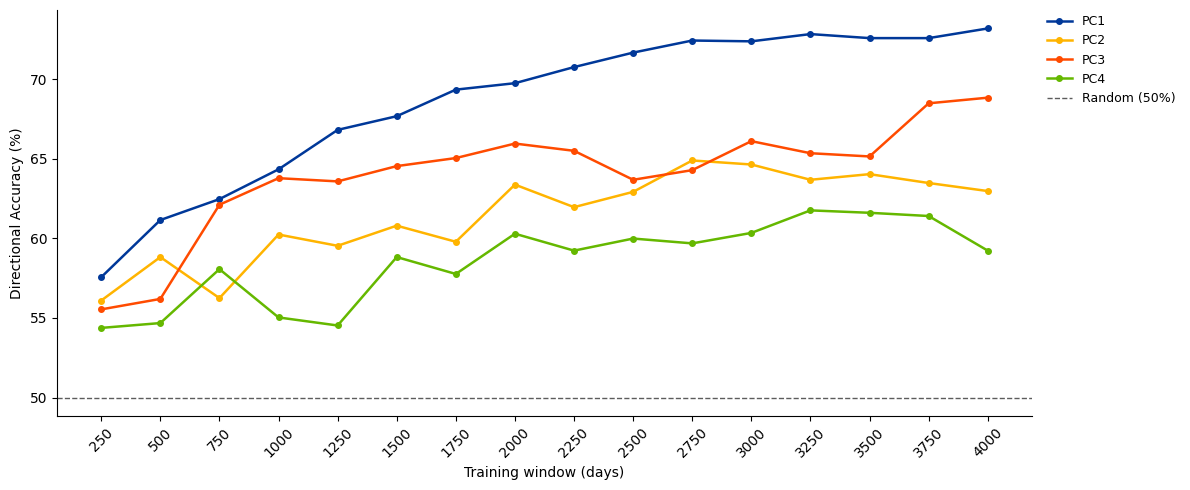

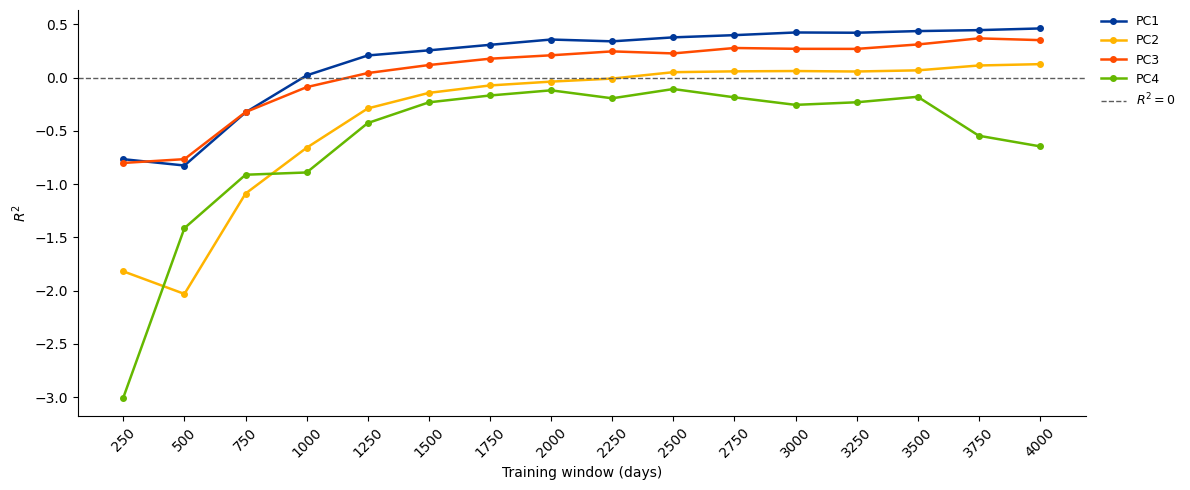

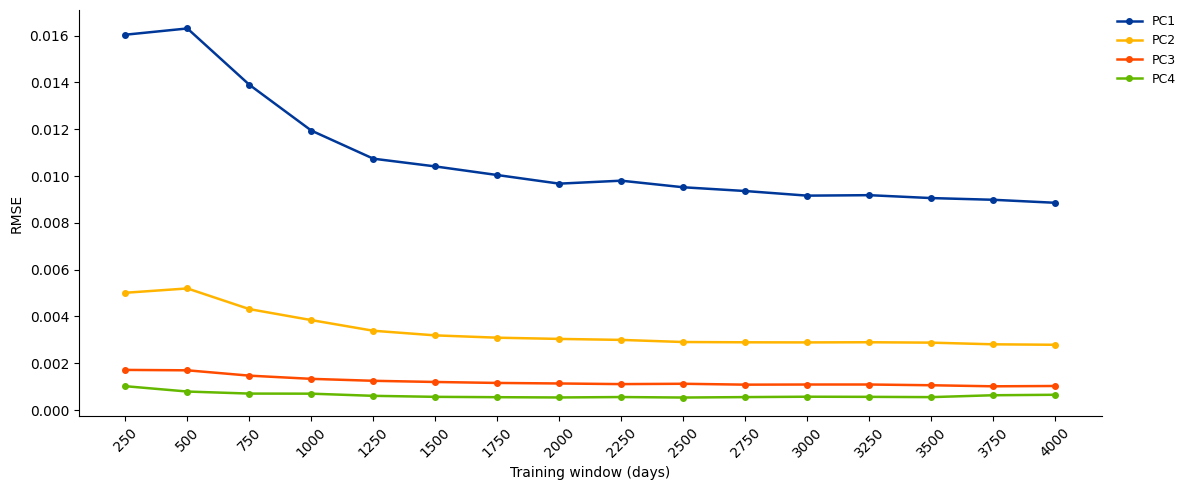


\begin{table}[htbp]
\centering
\caption{Rolling VAR Directional Accuracy by Training Window (Common Sample, $N=1977$)}
\label{tab:var_window_acc}
\begin{tabular}{rrrrr}
\hline\hline
Window & PC1 & PC2 & PC3 & PC4 \\
\hline
250 & 57.56\% & 56.10\% & 55.54\% & 54.38\% \\
500 & 61.15\% & 58.83\% & 56.20\% & 54.68\% \\
750 & 62.47\% & 56.25\% & 62.11\% & 58.07\% \\
1000 & 64.34\% & 60.24\% & 63.78\% & 55.03\% \\
1250 & 66.82\% & 59.53\% & 63.58\% & 54.53\% \\
1500 & 67.68\% & 60.80\% & 64.54\% & 58.83\% \\
1750 & 69.35\% & 59.79\% & 65.05\% & 57.76\% \\
2000 & 69.75\% & 63.38\% & 65.96\% & 60.29\% \\
2250 & 70.76\% & 61.96\% & 65.50\% & 59.23\% \\
2500 & 71.67\% & 62.92\% & 63.68\% & 59.99\% \\
2750 & 72.43\% & 64.90\% & 64.29\% & 59.69\% \\
3000 & 72.38\% & 64.64\% & 66.11\% & 60.34\% \\
3250 & 72.84\% & 63.68\% & 65.35\% & 61.76\% \\
3500 & 72.58\% & 64.04\% & 65.15\% & 61.61\% \\
3750 & 72.58\% & 63.48\% & 68.49\% & 61.41\% \\
4000 & 73.19\% & 62.97\% & 68.84\% & 59.23\% \\
\hline\hlin

In [3]:
"""
Rolling VAR Window Tuning
--------------------------
Fits rolling OLS VAR for each training window size, evaluates directional
accuracy, R², and RMSE per PC. Saves predictions and LaTeX tables.

Output: Data/VAR/VAR_WindowTuning.csv
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ============================================
# PARAMETERS
# ============================================

MARKET  = 'DE'
PCS     = [1, 2, 3, 4]
LAGS    = [22, 43, 64, 85, 106, 127, 148, 169, 190, 211]
HORIZON = 21

TRAIN_WINDOWS = [
    250, 500, 750, 1000, 1250, 1500, 1750, 2000,
    2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000
]
MAX_LAG    = max(LAGS)
N_FEATURES = len(LAGS) * len(PCS)

ECB_COLORS = ['#003899', '#FFB400', '#FF4B00', '#65B800']

fitting_path = os.path.join('Data', 'Fitting')
var_path     = os.path.join('Data', 'VAR')
os.makedirs(var_path, exist_ok=True)

# ============================================
# LOAD
# ============================================

df = pd.read_csv(os.path.join(fitting_path, f'{MARKET}_PCA4.csv'))
df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'])
df = df.sort_values('REFERENCE_DATE').reset_index(drop=True)

series = {pc: df[f'FUTURE_PC{pc}_DIRECTION_DIFF'].values.copy() for pc in PCS}
T      = len(df)

print(f'Loaded {T} observations')

# ============================================
# ROLLING VAR  (skip if CSV already exists)
# ============================================

out_file = os.path.join(var_path, 'VAR_WindowTuning.csv')

if os.path.exists(out_file):
    print(f'Cache found — loading predictions from {out_file}')
    df_out = pd.read_csv(out_file, parse_dates=['REFERENCE_DATE'])
    pred_store = {
        pc: {win: df_out[f'VAR_PC{pc}_WIN{win}'].values for win in TRAIN_WINDOWS}
        for pc in PCS
    }
else:
    pred_store = {
        pc: {win: np.full(T, np.nan) for win in TRAIN_WINDOWS}
        for pc in PCS
    }

    for win in TRAIN_WINDOWS:
        min_start   = MAX_LAG + win + HORIZON
        n_forecasts = T - min_start
        print(f'Window {win:>5}: {n_forecasts} forecasts', flush=True)

        for t in range(min_start, T):
            train_end   = t - HORIZON
            train_start = train_end - win

            X_tr   = np.array([
                [series[pc2][r - lag] for lag in LAGS for pc2 in PCS]
                for r in range(train_start, train_end)
            ])
            x_pred = np.array([[series[pc2][t - lag] for lag in LAGS for pc2 in PCS]])

            for pc in PCS:
                y_tr = np.array([series[pc][r] for r in range(train_start, train_end)])
                model = LinearRegression()
                model.fit(X_tr, y_tr)
                pred_store[pc][win][t] = model.predict(x_pred)[0]

        print(f'  done', flush=True)

    # Save
    df_out = df.copy()
    for pc in PCS:
        for win in TRAIN_WINDOWS:
            df_out[f'VAR_PC{pc}_WIN{win}'] = pred_store[pc][win]

    df_out.to_csv(out_file, index=False)
    print(f'\nSaved predictions → {out_file}')

# ============================================
# COMMON SAMPLE — indices where ALL windows have predictions
# ============================================

# Largest window starts forecasting last → defines common sample start
largest_win   = max(TRAIN_WINDOWS)
common_start  = MAX_LAG + largest_win + HORIZON
common_idx    = np.arange(common_start, T)
common_n      = len(common_idx)

print(f'\nCommon sample: index {common_start} → {T-1}  ({common_n} observations)')

# ============================================
# COMPUTE METRICS  (common sample only)
# ============================================

metrics = {win: {pc: {} for pc in PCS} for win in TRAIN_WINDOWS}

for win in TRAIN_WINDOWS:
    for pc in PCS:
        y     = series[pc][common_idx]
        y_hat = pred_store[pc][win][common_idx]

        dir_pred   = (y_hat >= 0).astype(int)
        dir_actual = (y     >= 0).astype(int)

        acc    = np.mean(dir_pred == dir_actual)
        rmse   = np.sqrt(np.mean((y - y_hat) ** 2))
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2     = 1 - ss_res / ss_tot

        metrics[win][pc] = {'acc': acc, 'rmse': rmse, 'r2': r2, 'n': common_n}

# ============================================
# PLOTS — one per metric
# ============================================

metric_configs = [
    ('acc',  'Directional Accuracy', lambda v: v * 100, '%',   50,  'Random (50%)'),
    ('r2',   '$R^2$',                lambda v: v,        '',    0,   '$R^2 = 0$'),
    ('rmse', 'RMSE',                 lambda v: v,        '',    None, None),
]

for metric_key, metric_label, transform, unit, baseline, bl_label in metric_configs:

    fig, ax = plt.subplots(figsize=(12, 5))

    for pc, color in zip(PCS, ECB_COLORS):
        vals = [transform(metrics[win][pc][metric_key]) for win in TRAIN_WINDOWS]
        ax.plot(TRAIN_WINDOWS, vals, '-o', color=color, lw=1.8,
                ms=4, label=f'PC{pc}')

    if baseline is not None:
        ax.axhline(baseline, color='#5C5C5C', lw=1.0, ls='--', label=bl_label)

    ax.set_xlabel('Training window (days)', fontsize=10)
    ax.set_ylabel(metric_label + (f' ({unit})' if unit else ''), fontsize=10)
    ax.set_xticks(TRAIN_WINDOWS)
    ax.tick_params(axis='x', rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, frameon=False,
              bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

    plt.tight_layout()
    plt.show()
    plt.close()

# ============================================
# LATEX TABLES
# ============================================

def fmt(v, metric):
    if metric == 'acc':  return f'{v*100:.2f}\\%'
    if metric == 'r2':   return f'{v:.4f}'
    if metric == 'rmse': return f'{v:.6f}'

for metric_key, metric_label in [('acc', 'Directional Accuracy'), ('r2', '$R^2$'), ('rmse', 'RMSE')]:
    print()
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    print(rf'\caption{{Rolling VAR {metric_label} by Training Window (Common Sample, $N={common_n}$)}}')
    print(rf'\label{{tab:var_window_{metric_key}}}')
    print(r'\begin{tabular}{r' + 'r' * len(PCS) + '}')
    print(r'\hline\hline')
    print('Window & ' + ' & '.join([f'PC{pc}' for pc in PCS]) + r' \\')
    print(r'\hline')
    for win in TRAIN_WINDOWS:
        vals = ' & '.join([fmt(metrics[win][pc][metric_key], metric_key) for pc in PCS])
        print(f'{win} & {vals} \\\\')
    print(r'\hline\hline')
    print(r'\end{tabular}')
    print(r'\end{table}')

## Out of sample VAR result with optimized training length

In [ ]:
"""
OOS Rolling VAR — Single Window
---------------------------------
Fits rolling OLS VAR with a fixed training window, saves predictions,
and prints LaTeX summary tables.

Output: Data/VAR/VAR_{WINDOW}.csv
"""

import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# ============================================
# PARAMETERS
# ============================================

MARKET   = 'DE'
PCS      = [1, 2, 3, 4]
LAGS     = [22, 43, 64, 85, 106, 127, 148, 169, 190, 211]
HORIZON  = 21
WINDOW   = 3000          # ← change this to switch window size

MAX_LAG    = max(LAGS)
N_FEATURES = len(LAGS) * len(PCS)
MIN_START  = MAX_LAG + WINDOW + HORIZON

fitting_path = os.path.join('Data', 'Fitting')
var_path     = os.path.join('Data', 'VAR')
os.makedirs(var_path, exist_ok=True)

# ============================================
# LOAD
# ============================================

df = pd.read_csv(os.path.join(fitting_path, f'{MARKET}_PCA4.csv'))
df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'])
df = df.sort_values('REFERENCE_DATE').reset_index(drop=True)

series = {pc: df[f'FUTURE_PC{pc}_DIRECTION_DIFF'].values.copy() for pc in PCS}
T      = len(df)

print(f'Loaded {T} observations')
print(f'Window: {WINDOW} | First forecast at index {MIN_START} | Forecasts: {T - MIN_START}')

# ============================================
# ROLLING OOS VAR
# ============================================

preds  = {pc: np.full(T, np.nan) for pc in PCS}

for t in range(MIN_START, T):
    train_end   = t - HORIZON
    train_start = train_end - WINDOW

    X_tr   = np.array([
        [series[pc2][r - lag] for lag in LAGS for pc2 in PCS]
        for r in range(train_start, train_end)
    ])
    x_pred = np.array([[series[pc2][t - lag] for lag in LAGS for pc2 in PCS]])

    for pc in PCS:
        y_tr = np.array([series[pc][r] for r in range(train_start, train_end)])
        model = LinearRegression()
        model.fit(X_tr, y_tr)
        preds[pc][t] = model.predict(x_pred)[0]

    if (t - MIN_START) % 500 == 0:
        print(f'  {(t - MIN_START) / (T - MIN_START) * 100:.1f}%', flush=True)

print('Done.')

# ============================================
# SAVE PREDICTIONS — merged into PCA4 fitting file
# ============================================

df_out = df.copy()
for pc in PCS:
    df_out[f'VAR_PC{pc}'] = preds[pc]

out_file = os.path.join(var_path, f'VAR_{WINDOW}.csv')
df_out.to_csv(out_file, index=False)
print(f'Saved → {out_file}')

# ============================================
# COMPUTE METRICS
# ============================================

def aic_bic(y, y_hat, n_params):
    n      = len(y)
    resid  = y - y_hat
    sse    = np.sum(resid ** 2)
    sigma2 = sse / n
    ll     = -n / 2 * np.log(2 * np.pi * sigma2) - sse / (2 * sigma2)
    k      = n_params + 1
    return -2 * ll + 2 * k, -2 * ll + k * np.log(n)

pc_metrics = {}
pc_resid   = {}

for pc in PCS:
    mask  = ~np.isnan(preds[pc])
    y     = series[pc][mask]
    y_hat = preds[pc][mask]
    resid = y - y_hat

    dir_pred   = (y_hat >= 0).astype(int)
    dir_actual = (y     >= 0).astype(int)
    acc  = np.mean(dir_pred == dir_actual)
    rmse = np.sqrt(np.mean(resid ** 2))
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot
    a, b = aic_bic(y, y_hat, N_FEATURES)

    pc_metrics[pc] = {'n': int(mask.sum()), 'acc': acc, 'r2': r2,
                      'rmse': rmse, 'aic': a, 'bic': b}
    pc_resid[pc]   = resid

# ============================================
# LATEX TABLE 1 — Model Performance
# ============================================

print()
print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{OOS Rolling VAR Performance --- Training Window ' + str(WINDOW) + r' Days}')
print(r'\label{tab:var_performance}')
print(r'\begin{tabular}{lrrrrr}')
print(r'\hline\hline')
print(r'PC & $N$ & Accuracy & $R^2$ & RMSE & AIC & BIC \\')
print(r'\hline')
for pc in PCS:
    m = pc_metrics[pc]
    print(f'PC{pc} & {m["n"]} & {m["acc"]:.2%} & {m["r2"]:.4f} & '
          f'{m["rmse"]:.6f} & {m["aic"]:.2f} & {m["bic"]:.2f} \\\\')
print(r'\hline\hline')
print(r'\end{tabular}')
print(r'\end{table}')

# ============================================
# LATEX TABLE 2 — Residual Summary
# ============================================

print()
print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{OOS Forecast Residual Statistics --- Training Window ' + str(WINDOW) + r' Days}')
print(r'\label{tab:var_residuals}')
print(r'\begin{tabular}{lrrrrrr}')
print(r'\hline\hline')
print(r'PC & Mean & Std.\ Dev. & Min & Q25 & Q75 & Max \\')
print(r'\hline')
for pc in PCS:
    r = pc_resid[pc]
    print(f'PC{pc} & {r.mean():.6f} & {r.std():.6f} & {r.min():.6f} & '
          f'{np.percentile(r, 25):.6f} & {np.percentile(r, 75):.6f} & '
          f'{r.max():.6f} \\\\')
print(r'\hline\hline')
print(r'\end{tabular}')
print(r'\end{table}')

Loaded 6209 observations
Window: 3000 | First forecast at index 3232 | Forecasts: 2977
  0.0%
  16.8%
  33.6%
  50.4%
  67.2%
  84.0%
Done.
Saved → Data\VAR\VAR_3000.csv

\begin{table}[htbp]
\centering
\caption{OOS Rolling VAR Performance --- Training Window 3000 Days}
\label{tab:var_performance}
\begin{tabular}{lrrrrr}
\hline\hline
PC & $N$ & Accuracy & $R^2$ & RMSE & AIC & BIC \\
\hline
PC1 & 2977 & 72.09% & 0.4092 & 0.008325 & -19980.27 & -19734.33 \\
PC2 & 2977 & 65.87% & 0.0532 & 0.002730 & -26619.07 & -26373.13 \\
PC3 & 2977 & 64.43% & 0.2628 & 0.001032 & -32411.67 & -32165.72 \\
PC4 & 2977 & 62.08% & -0.2065 & 0.000567 & -35974.91 & -35728.97 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{OOS Forecast Residual Statistics --- Training Window 3000 Days}
\label{tab:var_residuals}
\begin{tabular}{lrrrrrr}
\hline\hline
PC & Mean & Std.\ Dev. & Min & Q25 & Q75 & Max \\
\hline
PC1 & 0.000158 & 0.008324 & -0.036123 & -0.004629 & 0.004874 & 0.036659 \\